# Phase 3 — Encoder Fine-Tuning Ablation + Leakage Demonstration

Ömer Faruk Merey — Middle East Technical University

Phase 2 found that with **frozen** CLIP encoders the cross-attention architecture drives most of the gain and clean captions help only conditionally. Phase 3 introduces the *severe change* — unfreezing the encoder via **LoRA** — and a **leakage demonstration** (`Rleak`, raw hybrid captions with GT percentages).

| Group | Conditions | Encoder | Notes |
|---|---|---|---|
| Frozen (Phase 2) | R0a, R0b, R2b | frozen | loaded from `reports/phase-2/phase2_results.csv` |
| LoRA (Phase 3) | R0a-lora, R0b-lora, R2b-lora | LoRA r=8 | online training, 3 seeds |
| Leakage (Phase 3) | Rleak | frozen | raw `hybrid_gemma3-4b`, precomputed |


## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2
%pip install -q git+https://github.com/openai/CLIP.git spacy wandb tqdm scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path

REPO = Path.cwd().resolve().parents[1]
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import torch
import clip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.dataset import CONDITIONS, COMPOSITION_CLASSES
from src.precompute import precompute_images, precompute_texts
from src.train import TrainConfig, train_one_condition
from src.eval import predict_split, compute_metrics, aggregate_runs

DATASET_DIR = REPO / 'dataset'
IMAGES_DIR = DATASET_DIR / 'images'
CAPTIONS_CSV = DATASET_DIR / 'captions.csv'
CKPT_DIR = REPO / 'checkpoints'; CKPT_DIR.mkdir(exist_ok=True)
PRECOMPUTED_DIR = REPO / 'precomputed'; PRECOMPUTED_DIR.mkdir(exist_ok=True)
REPORTS_DIR = REPO / 'reports' / 'phase-3'; REPORTS_DIR.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print('device:', device)

clip_model, preprocess = clip.load('ViT-B/32', device=device)
clip_model.eval()
tokenizer = clip.tokenize

SEEDS = [42, 1337, 2024]

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


device: mps


## 2. Leakage demonstration (Rleak)

Train on raw `hybrid_gemma3-4b` captions (GT percentages intact). Frozen CLIP, so the precompute pipeline applies. Expected: test MSE collapses far below the leakage-free R0a (0.00707), confirming the model reads the answer from the text rather than the image.

In [3]:
# Precompute the raw-hybrid text embeddings (images.pt already exists from Phase 2)
precompute_images(CAPTIONS_CSV, IMAGES_DIR, PRECOMPUTED_DIR, clip_model, preprocess, device)
precompute_texts(CAPTIONS_CSV, PRECOMPUTED_DIR, clip_model, tokenizer, device,
                 conditions=('Rleak',))
print(sorted(p.name for p in PRECOMPUTED_DIR.iterdir()))

[skip] /Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/images.pt exists
[skip] /Users/ofm/Desktop/my_repostation/remote-sensing-caption-composition/precomputed/text_Rleak.pt exists
['filenames.json', 'images.pt', 'text_Rleak.pt']


In [4]:
USE_WANDB = True
for seed in SEEDS:
    ckpt = CKPT_DIR / f'Rleak_seed{seed}_best.pt'
    if ckpt.exists():
        print(f'-- skipping Rleak seed={seed}'); continue
    cfg = TrainConfig(condition='Rleak', seed=seed, epochs=30, batch_size=128,
                      use_wandb=USE_WANDB, checkpoint_dir=str(CKPT_DIR),
                      precomputed_dir=str(PRECOMPUTED_DIR),
                      wandb_tags=['phase3', 'leakage'])
    print(f'\n=== train Rleak seed={seed} ===')
    train_one_condition(cfg, CAPTIONS_CSV, IMAGES_DIR, clip_model, preprocess, tokenizer, device)

-- skipping Rleak seed=42
-- skipping Rleak seed=1337
-- skipping Rleak seed=2024


## 3. LoRA fine-tuning (R0a / R0b / R2b)

Online training (precompute is invalid once the encoder learns). On M4 each run is ~30–60 min; resume-friendly via checkpoints. `LORA_EPOCHS` defaults to 15 since fine-tuning converges faster than the frozen head and online training is expensive — raise to 30 on a CUDA GPU.

## 3a. LoRA smoke test (1 epoch, R0a, no W&B)

Validates the online LoRA path on M4/MPS and times one epoch before the full grid below. Uses a throwaway checkpoint dir so it doesn't collide with real runs.

In [5]:
import time
smoke_cfg = TrainConfig(
    condition='R0a', seed=42, epochs=1, batch_size=32,
    lr=5e-5, num_workers=0, use_wandb=False,
    checkpoint_dir=str(CKPT_DIR / 'smoke_lora'),
    lora=True, lora_r=8, lora_alpha=16, lora_last_k=6,
)
t0 = time.time()
out = train_one_condition(smoke_cfg, CAPTIONS_CSV, IMAGES_DIR, clip_model, preprocess, tokenizer, device)
dt = time.time() - t0
epochs, runs = 15, 9  # full grid: 3 conds x 3 seeds, 15 epochs each
print(f'\n1-epoch LoRA wall-clock: {dt:.0f}s')
print(f'=> full-grid estimate at {epochs} epochs: ~{dt*runs*epochs/3600:.1f} h')
out['history']

[lora] adapted 24 Linear layers
[R0a s42] ep00 train=0.03187 val=0.01259 best=0.01259@0 (80.6s)

1-epoch LoRA wall-clock: 81s
=> full-grid estimate at 15 epochs: ~3.0 h


[{'epoch': 0,
  'train_loss': 0.03187037716699498,
  'val_loss': 0.012588523541887602,
  'lr': 0.0,
  'elapsed_s': 80.58452606201172}]

In [6]:
LORA_CONDITIONS = ['R0a', 'R0b', 'R2b']
LORA_EPOCHS = 15

for cond in LORA_CONDITIONS:
    for seed in SEEDS:
        ckpt = CKPT_DIR / f'{cond}-lora_seed{seed}_best.pt'
        if ckpt.exists():
            print(f'-- skipping {cond}-lora seed={seed}'); continue
        cfg = TrainConfig(
            condition=cond, seed=seed, epochs=LORA_EPOCHS, batch_size=32,
            lr=5e-5, num_workers=2, use_wandb=USE_WANDB,
            checkpoint_dir=str(CKPT_DIR),
            lora=True, lora_r=8, lora_alpha=16, lora_last_k=6,
            wandb_tags=['phase3', 'lora'],
        )
        print(f'\n=== train {cond}-lora seed={seed} ===')
        train_one_condition(cfg, CAPTIONS_CSV, IMAGES_DIR, clip_model, preprocess, tokenizer, device)

-- skipping R0a-lora seed=42
-- skipping R0a-lora seed=1337
-- skipping R0a-lora seed=2024
-- skipping R0b-lora seed=42
-- skipping R0b-lora seed=1337
-- skipping R0b-lora seed=2024
-- skipping R2b-lora seed=42
-- skipping R2b-lora seed=1337
-- skipping R2b-lora seed=2024


### 3b. Stability fix — re-train diverged R0a-lora seed

`R0a-lora` seed 1337 diverged (test MSE ~0.013 vs ~0.0048 for seeds 42/2024). 
LoRA on the empty-caption condition is the least stable (no text signal through the 
cross-attention). We re-train it with **gradient clipping** (`grad_clip=1.0`), which 
caps the update norm and removes the divergence. Expand `RERUN_SEEDS` to all three to 
retrain R0a-lora under the identical clipped recipe for full consistency.

In [7]:
RERUN_SEEDS = [1337]   # set to [42, 1337, 2024] for a fully consistent clipped recipe
for seed in RERUN_SEEDS:
    ckpt = CKPT_DIR / f'R0a-lora_seed{seed}_best.pt'
    if ckpt.exists():
        ckpt.unlink()  # drop the diverged checkpoint so it retrains
    cfg = TrainConfig(
        condition='R0a', seed=seed, epochs=LORA_EPOCHS, batch_size=32,
        lr=5e-5, num_workers=2, use_wandb=USE_WANDB,
        checkpoint_dir=str(CKPT_DIR),
        lora=True, lora_r=8, lora_alpha=16, lora_last_k=6,
        grad_clip=1.0,
        wandb_tags=['phase3', 'lora', 'gradclip'],
    )
    print(f'\n=== retrain R0a-lora seed={seed} (grad_clip=1.0) ===')
    train_one_condition(cfg, CAPTIONS_CSV, IMAGES_DIR, clip_model, preprocess, tokenizer, device)


=== retrain R0a-lora seed=1337 (grad_clip=1.0) ===
[lora] adapted 24 Linear layers


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/ofm/.netrc.
wandb: Currently logged in as: mereyomerfaruk (team-lingua) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.che

[R0a s1337] ep00 train=0.03069 val=0.01228 best=0.01228@0 (81.8s)


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.che

...

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.che

[R0a s1337] ep13 train=0.00294 val=0.00505 best=0.00505@13 (83.9s)


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.che

[R0a s1337] ep14 train=0.00290 val=0.00504 best=0.00504@14 (83.5s)


elapsed_s,▁▄▃▆▇▄▄▃▅▆▆███▇
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
train_loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▃▂▂▂▃▁▂▂▁▁▁▁▁
best_epoch,14
best_val_loss,0.00504
elapsed_s,83.52358
epoch,14
lr,0
train_loss,0.0029


## 4. Evaluate Phase 3 checkpoints on the test set

In [8]:
rows = []

# Leakage (frozen, precomputed)
for seed in SEEDS:
    ckpt = CKPT_DIR / f'Rleak_seed{seed}_best.pt'
    if not ckpt.exists():
        print(f'!! missing {ckpt}'); continue
    out = predict_split('Rleak', seed, CAPTIONS_CSV, IMAGES_DIR, clip_model, preprocess,
                        tokenizer, device, ckpt, split='test',
                        precomputed_dir=str(PRECOMPUTED_DIR), batch_size=128)
    m = compute_metrics(out['pred'], out['gt']); m['condition'] = 'Rleak'; m['seed'] = seed
    rows.append(m)

# LoRA (online + adapters)
for cond in LORA_CONDITIONS:
    for seed in SEEDS:
        ckpt = CKPT_DIR / f'{cond}-lora_seed{seed}_best.pt'
        if not ckpt.exists():
            print(f'!! missing {ckpt}'); continue
        out = predict_split(cond, seed, CAPTIONS_CSV, IMAGES_DIR, clip_model, preprocess,
                            tokenizer, device, ckpt, split='test', batch_size=64,
                            lora=True, lora_r=8, lora_alpha=16, lora_last_k=6)
        m = compute_metrics(out['pred'], out['gt'])
        m['condition'] = f'{cond}-lora'; m['seed'] = seed
        rows.append(m)

phase3_df = pd.DataFrame(rows)
phase3_df.to_csv(REPORTS_DIR / 'phase3_results.csv', index=False)
phase3_df.groupby('condition')[['mse','mae','rmse','kl']].agg(['mean','std'])

mse                 mae                rmse            \
               mean       std      mean       std      mean       std   
condition                                                               
R0a-lora   0.004782  0.000104  0.032711  0.000578  0.069152  0.000752   
R0b-lora   0.004350  0.000098  0.032051  0.000106  0.065951  0.000740   
R2b-lora   0.004659  0.000213  0.032200  0.000525  0.068248  0.001550   
Rleak      0.001429  0.000114  0.019549  0.000754  0.037776  0.001521   

                 kl            
               mean       std  
condition                      
R0a-lora   0.110680  0.002796  
R0b-lora   0.107867  0.002840  
R2b-lora   0.109279  0.003656  
Rleak      0.061450  0.002677

## 5. Frozen vs LoRA comparison

       frozen      lora     delta      rel_%
R0a  0.007066  0.004782 -0.002284 -32.321498
R0b  0.011014  0.004350 -0.006664 -60.505202
R2b  0.007388  0.004659 -0.002728 -36.931607


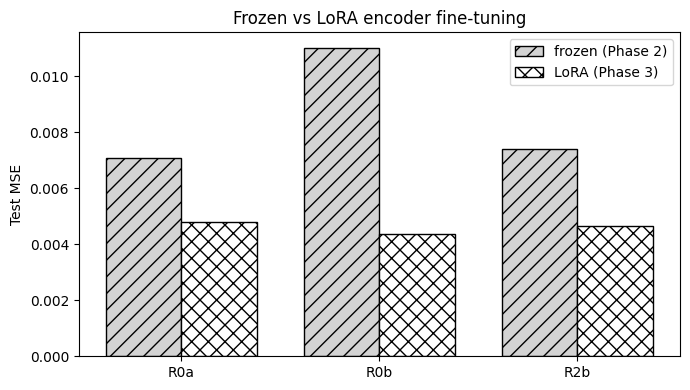

In [9]:
# Load frozen Phase 2 numbers
frozen = pd.read_csv(REPO / 'reports' / 'phase-2' / 'phase2_results.csv')
frozen_mse = frozen.groupby('condition')['mse'].mean()
p3_mse = phase3_df.groupby('condition')['mse'].mean()

comp = pd.DataFrame({
    'frozen': [frozen_mse.get(c, np.nan) for c in ['R0a','R0b','R2b']],
    'lora':   [p3_mse.get(f'{c}-lora', np.nan) for c in ['R0a','R0b','R2b']],
}, index=['R0a','R0b','R2b'])
comp['delta'] = comp['lora'] - comp['frozen']
comp['rel_%'] = 100 * comp['delta'] / comp['frozen']
print(comp)

x = np.arange(len(comp)); w = 0.38
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x-w/2, comp['frozen'], w, label='frozen (Phase 2)', color='lightgray', hatch='//', edgecolor='black')
ax.bar(x+w/2, comp['lora'],   w, label='LoRA (Phase 3)',   color='white',     hatch='xx', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(comp.index)
ax.set_ylabel('Test MSE'); ax.set_title('Frozen vs LoRA encoder fine-tuning')
ax.legend()
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'phase3_frozen_vs_lora.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Leakage demonstration bar

`Rleak` (raw hybrid, GT percentages in text) vs the leakage-free frozen R0a and best LoRA condition. A near-zero `Rleak` MSE confirms the Phase 1 leakage hypothesis: the model recovers the targets from the caption text.

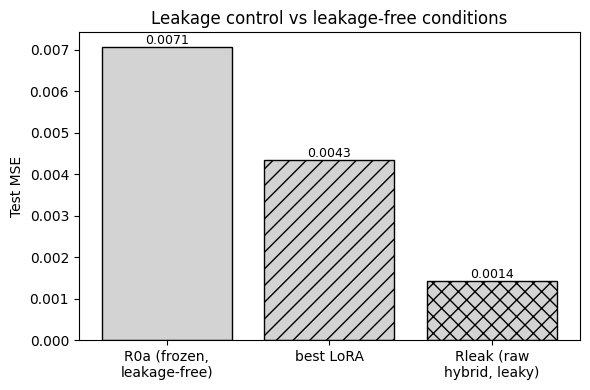

Rleak MSE = 0.00143  vs  frozen R0a = 0.00707


In [10]:
rleak_mse = phase3_df.query('condition == "Rleak"')['mse'].mean()
bars = {
    'R0a (frozen,\nleakage-free)': frozen_mse.get('R0a', np.nan),
    'best LoRA': float(np.nanmin(comp['lora'])),
    'Rleak (raw\nhybrid, leaky)': rleak_mse,
}
fig, ax = plt.subplots(figsize=(6,4))
b = ax.bar(list(bars.keys()), list(bars.values()),
           color='lightgray', edgecolor='black')
for bar, h in zip(b, ['', '//', 'xx']):
    bar.set_hatch(h)
ax.set_ylabel('Test MSE'); ax.set_title('Leakage control vs leakage-free conditions')
for bar, v in zip(b, bars.values()):
    ax.text(bar.get_x()+bar.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.savefig(REPORTS_DIR / 'phase3_leakage.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Rleak MSE = {rleak_mse:.5f}  vs  frozen R0a = {frozen_mse.get("R0a"):.5f}')